# RECYCLE NET — Final Model Training: ResNet-50

This notebook trains the **final ResNet-50 model** (no segmentation) on the full available data.  
This configuration was identified as the best-performing variant in `02_model_training_experiments.ipynb`,
achieving **~95.46% test accuracy**.

The trained model is saved as a `.pth` checkpoint for inference and deployment.

## 1. Libraries & Reproducibility

In [ ]:
import os
import time
import random

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Seed   : {SEED}')
print(f'Device : {DEVICE}')

Seed   : 42
Device : cuda


## 2. Configuration

In [ ]:
# Execution mode: 'local' reads CSVs from ../data/, 'online' downloads via kagglehub
EXECUTION_MODE = 'online'

# Hyper-parameters
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
LR          = 1e-3
NUM_CLASSES = 8

# Output
CHECKPOINT_PATH = 'model.pth'

# Class mappings
TARGET_CLASSES = {
    'glass': 0, 'paper': 1, 'cardboard': 2, 'plastic': 3, 'metal': 4,
    'battery': 5, 'biological': 6, 'textile': 7,
}
IDX_TO_CLASS = {
    0: 'Glass', 1: 'Paper', 2: 'Cardboard', 3: 'Plastic', 4: 'Metal',
    5: 'Battery', 6: 'Biological', 7: 'Textile',
}

print(f'Execution mode  : {EXECUTION_MODE}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Epochs          : {NUM_EPOCHS}')
print(f'Learning rate   : {LR}')
print(f'Num classes     : {NUM_CLASSES}')
print(f'Checkpoint path : {CHECKPOINT_PATH}')

Execution mode  : online
Batch size      : 32
Epochs          : 20
Learning rate   : 0.001
Num classes     : 8
Checkpoint path : model.pth


## 3. Data Loading

**Local mode** reads CSVs from `../data/` produced by `01_dataset_preparation.ipynb`.  
**Online mode** downloads both Kaggle datasets with `kagglehub` and rebuilds the train/val/test splits
using the same stratified 80/10/10 split.

In [ ]:
DATASETS_CONFIG_ONLINE = [
    {
        'path_key': 'ds1',
        'mapping': {
            'glass': 'glass', 'paper': 'paper', 'cardboard': 'cardboard',
            'plastic': 'plastic', 'metal': 'metal', 'trash': None,
        },
    },
    {
        'path_key': 'ds2',
        'mapping': {
            'brown-glass': 'glass', 'green-glass': 'glass', 'white-glass': 'glass',
            'paper': 'paper', 'cardboard': 'cardboard', 'plastic': 'plastic',
            'metal': 'metal', 'battery': 'battery', 'biological': 'biological',
            'clothes': 'textile', 'shoes': 'textile',
            'unknown': None, 'food-waste': None,
        },
    },
]


def build_samples_from_roots(path_ds1: str, path_ds2: str) -> list:
    paths_map = {'ds1': path_ds1, 'ds2': path_ds2}
    samples = []
    for cfg in DATASETS_CONFIG_ONLINE:
        root = paths_map[cfg['path_key']]
        for dirpath, _, files in os.walk(root):
            cls_name = os.path.basename(dirpath).lower()
            if cls_name not in cfg['mapping']:
                continue
            target = cfg['mapping'][cls_name]
            if target is None:
                continue
            label = TARGET_CLASSES[target]
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    samples.append((os.path.join(dirpath, f), label))
    return samples


if EXECUTION_MODE == 'local':
    print('Loading local CSVs ...')
    train_df = pd.read_csv('../data/train.csv')
    val_df   = pd.read_csv('../data/val.csv')
    test_df  = pd.read_csv('../data/test.csv')
    RAW_DIR  = os.path.abspath('../data/raw')
    for df in (train_df, val_df, test_df):
        df['path'] = df['path'].apply(
            lambda p: p if os.path.isabs(p) else os.path.join(RAW_DIR, p)
        )
else:
    import kagglehub
    from sklearn.model_selection import train_test_split as _tts

    print('Downloading Dataset 1 (Base) ...')
    path_ds1 = kagglehub.dataset_download('zlatan599/garbage-dataset-classification')
    print('Downloading Dataset 2 (Industrial) ...')
    path_ds2 = kagglehub.dataset_download('mostafaabla/garbage-classification')

    all_samples = build_samples_from_roots(path_ds1, path_ds2)
    all_paths   = [s[0] for s in all_samples]
    all_labels  = [s[1] for s in all_samples]
    idx_all     = list(range(len(all_samples)))

    train_idx, temp_idx = _tts(idx_all, test_size=0.2, stratify=all_labels, random_state=SEED)
    temp_labels         = [all_labels[i] for i in temp_idx]
    val_idx, test_idx   = _tts(temp_idx, test_size=0.5, stratify=temp_labels, random_state=SEED)

    train_df = pd.DataFrame({'path': [all_paths[i] for i in train_idx], 'label': [all_labels[i] for i in train_idx]})
    val_df   = pd.DataFrame({'path': [all_paths[i] for i in val_idx],   'label': [all_labels[i] for i in val_idx]})
    test_df  = pd.DataFrame({'path': [all_paths[i] for i in test_idx],  'label': [all_labels[i] for i in test_idx]})

print(f'Data loaded.')
print(f'  Train : {len(train_df):>5} samples')
print(f'  Val   : {len(val_df):>5} samples')
print(f'  Test  : {len(test_df):>5} samples')

Using Colab cache for faster access to the 'garbage-dataset-classification' dataset.
Using Colab cache for faster access to the 'garbage-classification' dataset.
Data loaded.
  Train : 20975 samples
  Val   :  2622 samples
  Test  :  2622 samples


## 4. Dataset & DataLoaders

In [ ]:
class GarbageDataset(Dataset):
    """Dataset backed by a DataFrame with columns [path, label]."""

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_loader = DataLoader(
    GarbageDataset(train_df, train_transforms),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0, pin_memory=True,
)
val_loader = DataLoader(
    GarbageDataset(val_df, val_test_transforms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True,
)
test_loader = DataLoader(
    GarbageDataset(test_df, val_test_transforms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True,
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 655
Val batches   : 82
Test batches  : 82


## 5. Model: ResNet-50

ImageNet-pretrained backbone with **all layers frozen**.  
Only the final fully-connected head is replaced and trained.

In [ ]:
def build_resnet50(num_classes: int = NUM_CLASSES) -> nn.Module:
    """ResNet-50 with frozen backbone and a new classification head."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)


model = build_resnet50()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  (head only)')

Total params     : 23,524,424
Trainable params : 16,392  (head only)


## 6. Training Loop

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    """One training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc='train'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluation pass. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc='eval'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None
t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    print(
        f'Epoch {epoch:>2}/{NUM_EPOCHS} | '
        f'train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | '
        f'val loss: {va_loss:.4f}  acc: {va_acc:.4f}'
    )

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed:.0f}s')
print(f'Best val accuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')

train:   0%|          | 0/655 [00:00<?, ?it/s]

eval:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch  1/20 | train loss: 0.5169  acc: 0.8466 | val loss: 0.2764  acc: 0.9123


train:   0%|          | 0/655 [00:00<?, ?it/s]

eval:   0%|          | 0/82 [00:00<?, ?it/s]

...

eval:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 19/20 | train loss: 0.1377  acc: 0.9547 | val loss: 0.1346  acc: 0.9512


train:   0%|          | 0/655 [00:00<?, ?it/s]

eval:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 20/20 | train loss: 0.1373  acc: 0.9552 | val loss: 0.1335  acc: 0.9542

Training complete in 4125s
Best val accuracy : 0.9542 (95.42%)


## 7. Save Checkpoint

In [ ]:
torch.save(
    {
        'model_state_dict': best_weights,
        'num_classes':      NUM_CLASSES,
        'idx_to_class':     IDX_TO_CLASS,
        'best_val_acc':     best_val_acc,
        'history':          history,
        'hyperparameters': {
            'arch':       'resnet50',
            'epochs':     NUM_EPOCHS,
            'lr':         LR,
            'batch_size': BATCH_SIZE,
            'seed':       SEED,
        },
    },
    CHECKPOINT_PATH,
)

size_mb = os.path.getsize(CHECKPOINT_PATH) / 1e6
print(f'Checkpoint saved to "{CHECKPOINT_PATH}"  ({size_mb:.1f} MB)')

Checkpoint saved to "model.pth"  (94.4 MB)


## 8. Test Set Evaluation

In [ ]:
@torch.no_grad()
def get_all_preds_labels(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        outputs = model(images.to(DEVICE))
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


# Restore best weights before evaluating on test
model.load_state_dict(best_weights)

te_loss, te_acc = evaluate(model, test_loader, criterion)
print(f'Test loss     : {te_loss:.4f}')
print(f'Test accuracy : {te_acc:.4f} ({te_acc*100:.2f}%)')

preds, labels = get_all_preds_labels(model, test_loader)
class_names   = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

print('\nClassification Report:')
print(classification_report(labels, preds, target_names=class_names, digits=4))

eval:   0%|          | 0/82 [00:00<?, ?it/s]

Test loss     : 0.2797
Test accuracy : 0.9104 (91.04%)

Classification Report:
              precision    recall  f1-score   support

       Glass     0.9027    0.9047    0.9037       451
       Paper     0.8697    0.9110    0.8899       337
   Cardboard     0.9193    0.8452    0.8807       310
     Plastic     0.8861    0.7905    0.8356       315
       Metal     0.8176    0.9091    0.8609       286
     Battery     0.9010    0.9681    0.9333        94
  Biological     0.9677    0.9091    0.9375        99
     Textile     0.9743    0.9863    0.9803       730

    accuracy                         0.9104      2622
   macro avg     0.9048    0.9030    0.9027      2622
weighted avg     0.9115    0.9104    0.9100      2622



## 9. Learning Curves & Confusion Matrix

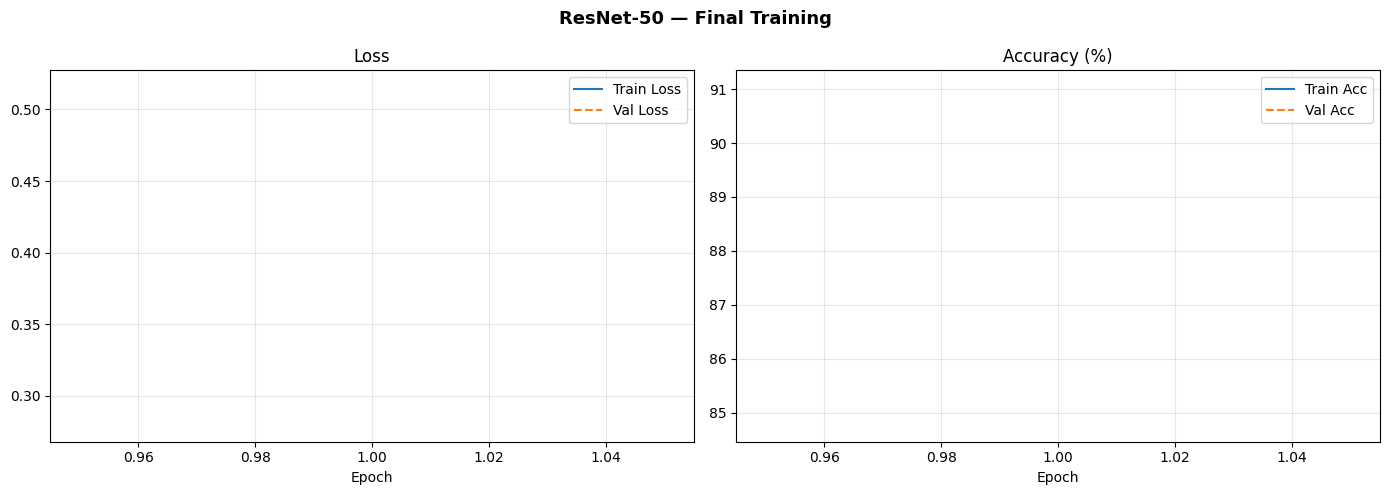

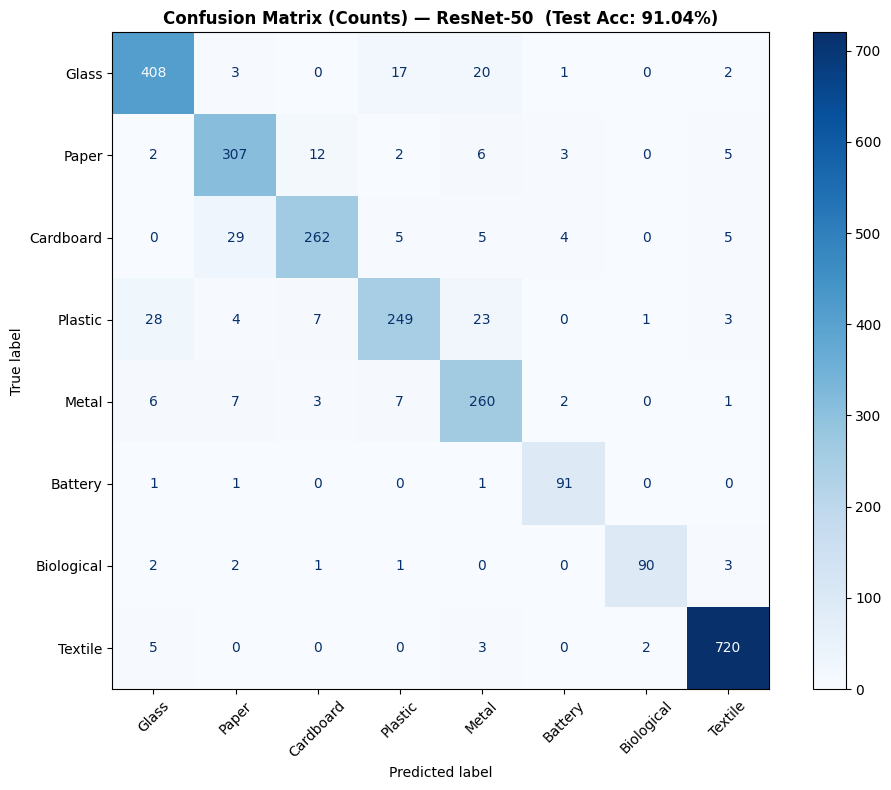

TypeError: ConfusionMatrixDisplay.__init__() got an unexpected keyword argument 'normalize'

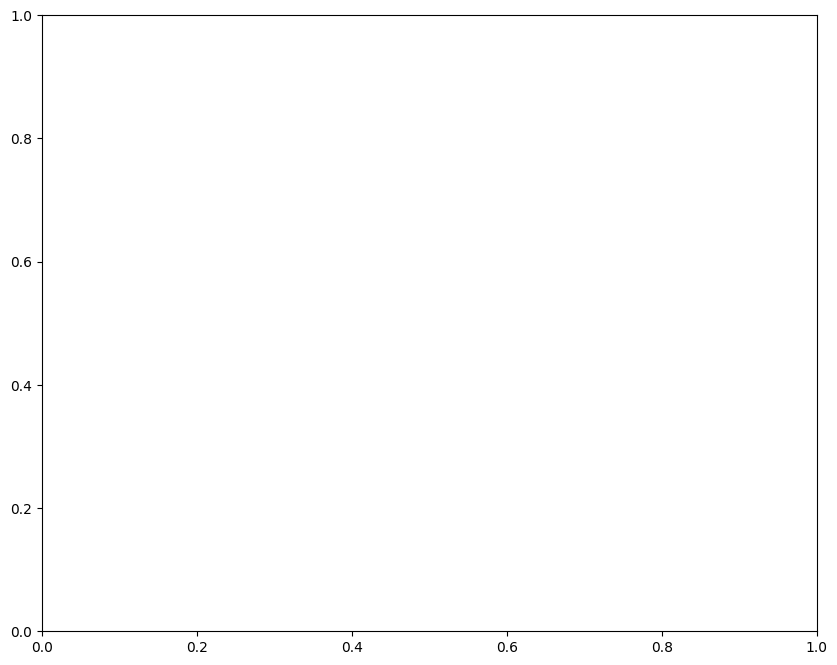

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet-50 — Final Training', fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train Acc')
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Val Acc', linestyle='--')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion matrix (Absolute Counts)
cm = confusion_matrix(labels, preds, labels=np.arange(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45
)
ax.set_title(
    f'Confusion Matrix (Counts) — ResNet-50  (Test Acc: {te_acc*100:.2f}%)',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

# Confusion matrix (Percentages per class)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names, normalize='true').plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45
)
ax.set_title(
    f'Confusion Matrix (Percentages) — ResNet-50  (Test Acc: {te_acc*100:.2f}%)',
    fontweight='bold'
)
plt.tight_layout()
plt.show()